# Sistema de Reconocimiento de Expresiones Faciales
## Fase 2 - Proyecto de Machine Learning

**Materia:** Machine y Deep Learning 
**Universidad Autónoma de Aguascalientes**  
**Alumno:** Carlos Daniel Torres Macías 
**Fecha:** 20/03/2026
**Profesor:** Dr. Francisco Javier Luna Rosas

----

**Expresiones a detectar:** Feliz, Enojado, Triste, Sorprendido, Neutral

Este notebook contiene:
1. **Recoleccion de Datos** - Captura de imagenes faciales con webcam
2. **Preprocesamiento** - Deteccion de rostro y extraccion de caracteristicas
3. **Entrenamiento de Modelos** - 7 algoritmos de ML incluyendo NNBP
4. **Evaluacion Comparativa** - Tabla comparativa de metricas
5. **Reconocimiento en Tiempo Real** - Deteccion de expresiones con webcam


## 1. Instalacion de Dependencias e Importaciones

In [1]:
# Instalar dependencias necesarias
!pip install opencv-python scikit-learn xgboost tensorflow matplotlib seaborn scikit-image


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
from datetime import datetime

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Extraccion de caracteristicas
from skimage.feature import hog, local_binary_pattern

# TensorFlow/Keras para NNBP
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")
print("Todas las librerias importadas correctamente.")
print("OpenCV version:", cv2.__version__)
print("TensorFlow version:", tf.__version__)


I0000 00:00:1774900248.740556   10817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774900248.741659   10817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774900248.844778   10817 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774900251.523446   10817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Todas las librerias importadas correctamente.
OpenCV version: 4.13.0
TensorFlow version: 2.21.0


## 2. Configuracion del Proyecto

In [3]:
# Configuracion
EMOCIONES = ["Feliz", "Enojado", "Triste", "Sorprendido", "Neutral"]
DATA_DIR = "dataset_expresiones"
MODELS_DIR = "modelos"
IMG_SIZE = 48  # Tamano de imagenes de rostros

# Crear directorios
os.makedirs(MODELS_DIR, exist_ok=True)
for emocion in EMOCIONES:
    os.makedirs(os.path.join(DATA_DIR, emocion), exist_ok=True)

print("Directorios creados:")
for emocion in EMOCIONES:
    path = os.path.join(DATA_DIR, emocion)
    n_imgs = len([f for f in os.listdir(path) if f.endswith((".jpg", ".png"))]) if os.path.exists(path) else 0
    print(f"  {emocion}: {n_imgs} imagenes")


Directorios creados:
  Feliz: 0 imagenes
  Enojado: 0 imagenes
  Triste: 0 imagenes
  Sorprendido: 0 imagenes
  Neutral: 0 imagenes


## 3. Recoleccion de Datos con Webcam

### Instrucciones:
1. Ejecuta la celda siguiente
2. Se abrira tu webcam
3. Presiona las siguientes teclas para capturar imagenes de cada emocion:
   - **1** = Feliz
   - **2** = Enojado
   - **3** = Triste
   - **4** = Sorprendido
   - **5** = Neutral
4. Se recomienda capturar **al menos 100 imagenes por emocion** (minimo 50)
5. Mueve ligeramente tu cabeza, varia la intensidad de la expresion
6. Presiona **q** para salir


In [4]:
def capturar_datos():
    """Captura imagenes faciales con la webcam organizadas por emocion."""

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: No se pudo abrir la webcam")
        return

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    tecla_emocion = {"1": "Feliz", "2": "Enojado", "3": "Triste",
                     "4": "Sorprendido", "5": "Neutral"}
    contadores = {}
    for e in EMOCIONES:
        carpeta = os.path.join(DATA_DIR, e)
        contadores[e] = len([f for f in os.listdir(carpeta) if f.endswith((".jpg",".png"))])

    print("=" * 60)
    print("CAPTURA DE EXPRESIONES FACIALES")
    print("=" * 60)
    print("Teclas: 1=Feliz, 2=Enojado, 3=Triste, 4=Sorprendido, 5=Neutral")
    print("Presiona q para salir")
    print("=" * 60)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        display = frame.copy()
        for (x, y, w, h) in faces:
            cv2.rectangle(display, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Mostrar contadores
        y_offset = 30
        for emo, count in contadores.items():
            cv2.putText(display, f"{emo}: {count}", (10, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            y_offset += 25

        cv2.putText(display, "1:Feliz 2:Enojado 3:Triste 4:Sorpr 5:Neutral q:Salir",
                   (10, display.shape[0] - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

        cv2.imshow("Captura de Expresiones Faciales", display)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break

        key_char = chr(key) if key != 255 else ""

        if key_char in tecla_emocion and len(faces) > 0:
            emocion = tecla_emocion[key_char]
            (x, y, w, h) = faces[0]

            # Extraer rostro con margen
            margen = 20
            y1 = max(0, y - margen)
            y2 = min(frame.shape[0], y + h + margen)
            x1 = max(0, x - margen)
            x2 = min(frame.shape[1], x + w + margen)

            rostro = gray[y1:y2, x1:x2]
            rostro = cv2.resize(rostro, (IMG_SIZE, IMG_SIZE))

            filename = f"{emocion}_{contadores[emocion]:04d}.jpg"
            filepath = os.path.join(DATA_DIR, emocion, filename)
            cv2.imwrite(filepath, rostro)

            contadores[emocion] += 1
            print(f"Guardada: {filepath} ({contadores[emocion]} imgs de {emocion})")

    cap.release()
    cv2.destroyAllWindows()

    print()
    print("=" * 60)
    print("RESUMEN DE CAPTURA")
    print("=" * 60)
    total = 0
    for emo, count in contadores.items():
        print(f"  {emo}: {count} imagenes")
        total += count
    print(f"  TOTAL: {total} imagenes")

# EJECUTAR CAPTURA
capturar_datos()


CAPTURA DE EXPRESIONES FACIALES
Teclas: 1=Feliz, 2=Enojado, 3=Triste, 4=Sorprendido, 5=Neutral
Presiona q para salir


QFontDatabase: Cannot find font directory /home/danieltorres/miniconda3/envs/firmas/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/danieltorres/miniconda3/envs/firmas/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/danieltorres/miniconda3/envs/firmas/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/danieltorres/miniconda3/envs/firmas/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconf

Guardada: dataset_expresiones/Feliz/Feliz_0000.jpg (1 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0001.jpg (2 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0002.jpg (3 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0003.jpg (4 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0004.jpg (5 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0005.jpg (6 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0006.jpg (7 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0007.jpg (8 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0008.jpg (9 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0009.jpg (10 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0010.jpg (11 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0011.jpg (12 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0012.jpg (13 imgs de Feliz)
Guardada: dataset_expresiones/Feliz/Feliz_0013.jpg (14 imgs de Feliz)
Guardada: dataset_expresiones

## 4. Carga y Preprocesamiento de Datos

In [5]:
def cargar_dataset():
    """Carga todas las imagenes del dataset."""
    imagenes = []
    etiquetas = []

    for emocion in EMOCIONES:
        carpeta = os.path.join(DATA_DIR, emocion)
        archivos = [f for f in os.listdir(carpeta) if f.endswith((".jpg", ".png"))]

        for archivo in archivos:
            filepath = os.path.join(carpeta, archivo)
            img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                imagenes.append(img)
                etiquetas.append(emocion)

    print(f"Total de imagenes cargadas: {len(imagenes)}")
    for emo in EMOCIONES:
        count = etiquetas.count(emo)
        print(f"  {emo}: {count}")

    return np.array(imagenes), np.array(etiquetas)

imagenes, etiquetas = cargar_dataset()


Total de imagenes cargadas: 259
  Feliz: 55
  Enojado: 50
  Triste: 50
  Sorprendido: 52
  Neutral: 52


## 5. Extraccion de Caracteristicas

Se utilizan tres tipos de caracteristicas combinadas:
1. **Pixeles normalizados** - Vector de intensidades (48x48 = 2304 features)
2. **HOG (Histogram of Oriented Gradients)** - Captura bordes y formas del rostro
3. **LBP (Local Binary Patterns)** - Captura texturas faciales

La combinacion de estas 3 tecnicas da un vector de caracteristicas robusto para clasificar expresiones.


In [6]:
def extraer_hog(imagen):
    """Extrae caracteristicas HOG de una imagen."""
    features = hog(
        imagen,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )
    return features


def extraer_lbp(imagen):
    """Extrae histograma LBP de una imagen."""
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(imagen, n_points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, n_points + 3),
                           density=True)
    return hist


def extraer_caracteristicas(imagenes):
    """Extrae caracteristicas combinadas: pixeles + HOG + LBP."""
    features_list = []

    print("Extrayendo caracteristicas...")
    for i, img in enumerate(imagenes):
        # 1. Pixeles normalizados
        pixeles = img.flatten() / 255.0

        # 2. HOG
        feat_hog = extraer_hog(img)

        # 3. LBP
        feat_lbp = extraer_lbp(img)

        # Combinar todo
        combinado = np.hstack([pixeles, feat_hog, feat_lbp])
        features_list.append(combinado)

        if (i + 1) % 100 == 0:
            print(f"  Procesadas {i+1}/{len(imagenes)} imagenes...")

    X = np.array(features_list)
    print(f"  Procesadas {len(imagenes)}/{len(imagenes)} imagenes...")
    print()
    print("Caracteristicas extraidas exitosamente:")
    print(f"  Dimension pixeles: {IMG_SIZE*IMG_SIZE}")
    print(f"  Dimension HOG: {len(feat_hog)}")
    print(f"  Dimension LBP: {len(feat_lbp)}")
    print(f"  Dimension total combinada: {X.shape[1]}")

    return X


X = extraer_caracteristicas(imagenes)
y = etiquetas.copy()
print(f"Dataset final: {X.shape[0]} muestras, {X.shape[1]} caracteristicas")


Extrayendo caracteristicas...
  Procesadas 100/259 imagenes...
  Procesadas 200/259 imagenes...
  Procesadas 259/259 imagenes...

Caracteristicas extraidas exitosamente:
  Dimension pixeles: 2304
  Dimension HOG: 900
  Dimension LBP: 26
  Dimension total combinada: 3230
Dataset final: 259 muestras, 3230 caracteristicas


## 6. Division del Dataset y Preparacion

In [7]:
# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Clases:", le.classes_)
print("Codificacion:", dict(zip(le.classes_, le.transform(le.classes_))))

# Division Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalar caracteristicas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test_scaled.shape[0]} muestras")

# Distribucion de clases
print()
print("Distribucion en entrenamiento:")
for i, emo in enumerate(le.classes_):
    count = np.sum(y_train == i)
    pct = count / len(y_train) * 100
    print(f"  {emo}: {count} ({pct:.1f}%)")


Clases: ['Enojado' 'Feliz' 'Neutral' 'Sorprendido' 'Triste']
Codificacion: {np.str_('Enojado'): np.int64(0), np.str_('Feliz'): np.int64(1), np.str_('Neutral'): np.int64(2), np.str_('Sorprendido'): np.int64(3), np.str_('Triste'): np.int64(4)}
Conjunto de entrenamiento: 207 muestras
Conjunto de prueba: 52 muestras

Distribucion en entrenamiento:
  Enojado: 40 (19.3%)
  Feliz: 44 (21.3%)
  Neutral: 42 (20.3%)
  Sorprendido: 41 (19.8%)
  Triste: 40 (19.3%)


## 7. Visualizacion del Dataset

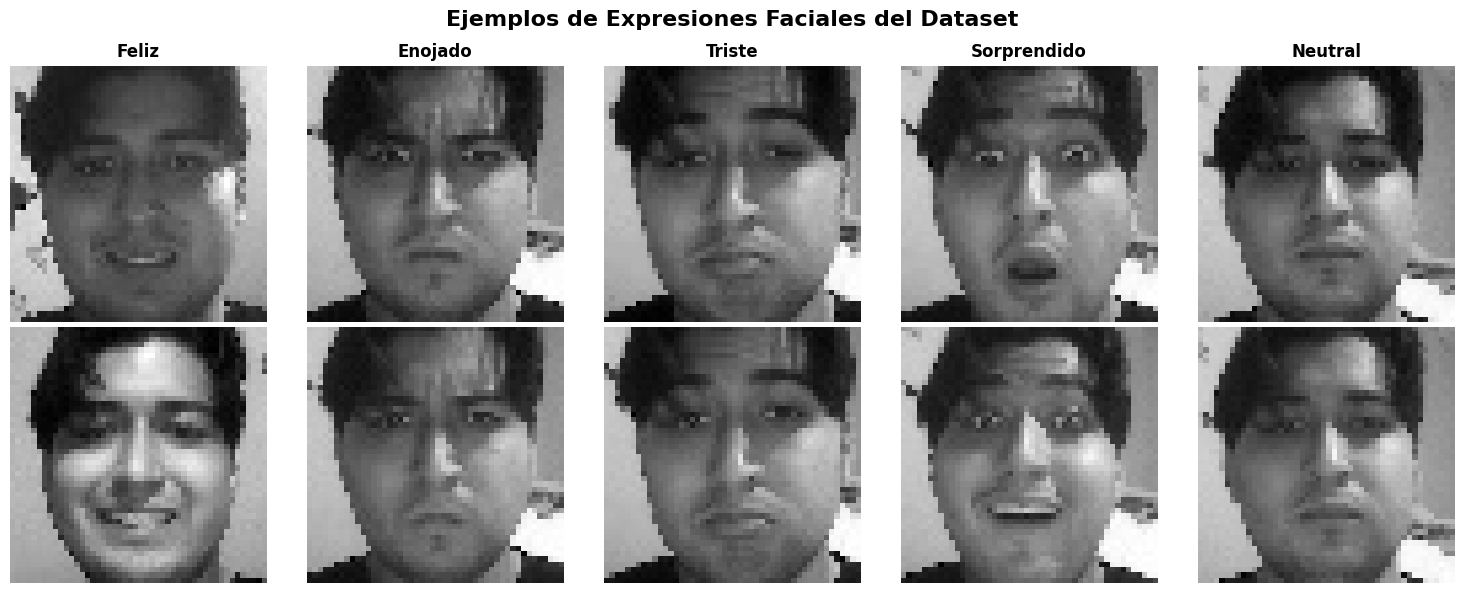

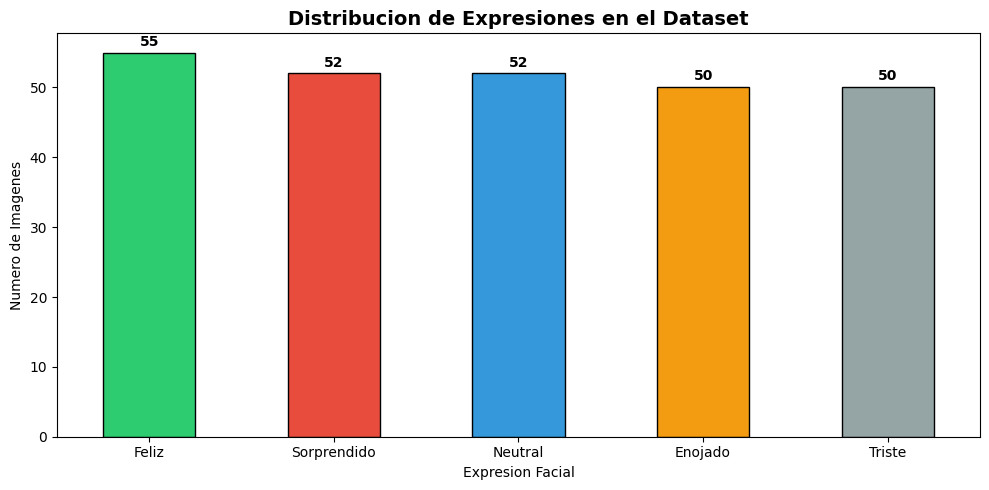

In [8]:
# Mostrar ejemplos de cada emocion
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Ejemplos de Expresiones Faciales del Dataset", fontsize=16, fontweight="bold")

for i, emocion in enumerate(EMOCIONES):
    mask = y == emocion
    imgs_emocion = imagenes[mask]

    if len(imgs_emocion) > 0:
        axes[0, i].imshow(imgs_emocion[0], cmap="gray")
        axes[0, i].set_title(emocion, fontsize=12, fontweight="bold")
        axes[0, i].axis("off")

        if len(imgs_emocion) > 1:
            axes[1, i].imshow(imgs_emocion[1], cmap="gray")
        axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("ejemplos_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

# Distribucion de clases
fig, ax = plt.subplots(figsize=(10, 5))
conteo = pd.Series(y).value_counts()
colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#95a5a6"]
conteo.plot(kind="bar", color=colors, ax=ax, edgecolor="black")
ax.set_title("Distribucion de Expresiones en el Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Expresion Facial")
ax.set_ylabel("Numero de Imagenes")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("distribucion_dataset.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Entrenamiento de Modelos de Machine Learning

### Algoritmos implementados:
1. **NNBP** - Red Neuronal con Backpropagation (Keras)
2. **Bosques Aleatorios** (Random Forest)
3. **AdaBoost** (ADABoosting)
4. **XGBoost** (XGBoosting)
5. **SVM** (Support Vector Machine)
6. **Arboles de Decision** (Decision Tree)
7. **KNN** (K-Nearest Neighbors)


In [9]:
# ==============================================
# MODELO 1: NNBP - Red Neuronal Backpropagation
# ==============================================
print("=" * 60)
print("MODELO 1: NNBP (Red Neuronal con Backpropagation)")
print("=" * 60)

n_clases = len(EMOCIONES)
n_features = X_train_scaled.shape[1]

# Convertir etiquetas a one-hot para Keras
y_train_cat = to_categorical(y_train, n_clases)
y_test_cat = to_categorical(y_test, n_clases)

# Arquitectura de la Red Neuronal
modelo_nn = Sequential([
    Dense(512, activation="relu", input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(n_clases, activation="softmax")
])

modelo_nn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_nn.summary()

# Entrenamiento
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

historia = modelo_nn.fit(
    X_train_scaled, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
y_pred_nn = np.argmax(modelo_nn.predict(X_test_scaled), axis=1)
acc_nn = accuracy_score(y_test, y_pred_nn)
print()
print(f"Precision NNBP: {acc_nn:.6f}")


MODELO 1: NNBP (Red Neuronal con Backpropagation)


E0000 00:00:1774900432.802031   10817 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,654,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,830,661 (6.98 MB)

 Trainable params: 1,828,869 (6.98 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3576 - loss: 1.7592 - val_accuracy: 0.5238 - val_loss: 1.1593
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6788 - loss: 0.8586 - val_accuracy: 0.7381 - val_loss: 0.7914
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8182 - loss: 0.5194 - val_accuracy: 0.9048 - val_loss: 0.4753
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8909 - loss: 0.3623 - val_accuracy: 0.9286 - val_loss: 0.3452
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9091 - loss: 0.2752 - val_accuracy: 0.9524 - val_loss: 0.2619
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9030 - loss: 0.3042 - val_accuracy: 0.9762 - val_loss: 0.1974
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9758 - loss: 0.1575 - val_accuracy: 0.9286 - val_loss: 0.2080
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9636 - loss: 0.1559 - val_accuracy: 0.9286 - val_loss:

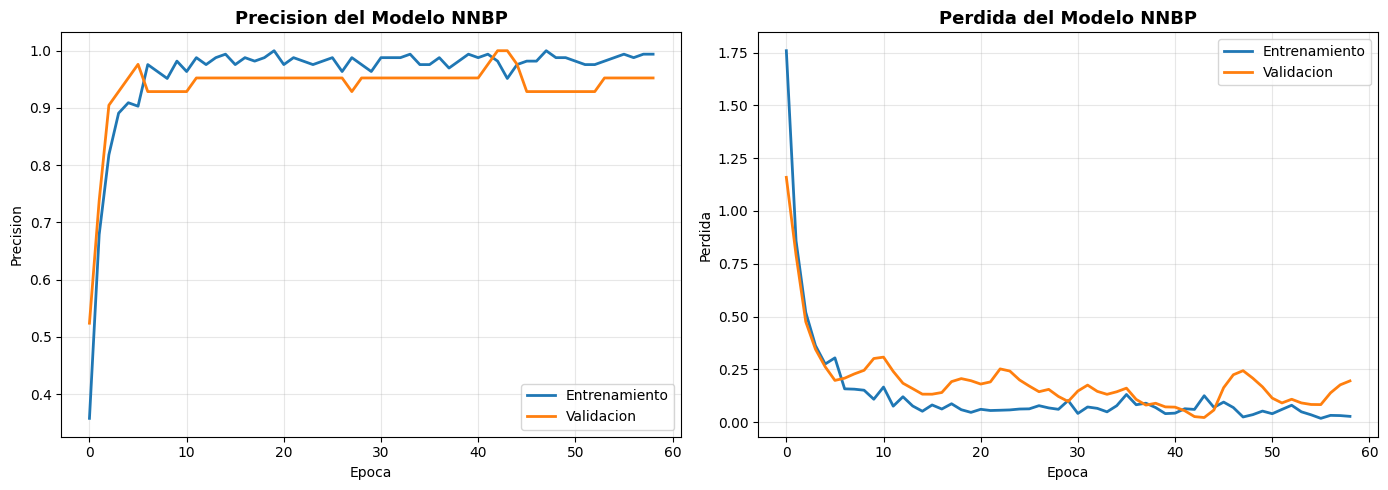

In [10]:
# Graficas de entrenamiento NNBP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historia.history["accuracy"], label="Entrenamiento", linewidth=2)
ax1.plot(historia.history["val_accuracy"], label="Validacion", linewidth=2)
ax1.set_title("Precision del Modelo NNBP", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoca")
ax1.set_ylabel("Precision")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historia.history["loss"], label="Entrenamiento", linewidth=2)
ax2.plot(historia.history["val_loss"], label="Validacion", linewidth=2)
ax2.set_title("Perdida del Modelo NNBP", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Perdida")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("nnbp_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# ==============================================
# MODELOS 2-7: Algoritmos de Scikit-Learn + XGBoost
# ==============================================

modelos = {
    "Bosques Aleatorios": RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
    ),
    "ADABoosting": AdaBoostClassifier(
        n_estimators=150, learning_rate=0.1, random_state=42
    ),
    "XGBoosting": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="mlogloss"
    ),
    "SVM": SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True),
    "Arboles de Decision": DecisionTreeClassifier(max_depth=15, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)
}

resultados = {}
predicciones = {}

# Agregar resultado de NNBP
resultados["NNBP"] = {"modelo": modelo_nn, "y_pred": y_pred_nn, "accuracy": acc_nn}
predicciones["NNBP"] = y_pred_nn

for nombre, modelo in modelos.items():
    print()
    print("=" * 60)
    print(f"Entrenando: {nombre}")
    print("=" * 60)

    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    resultados[nombre] = {"modelo": modelo, "y_pred": y_pred, "accuracy": acc}
    predicciones[nombre] = y_pred

    print(f"Precision: {acc:.6f}")
    print(f"Error: {1 - acc:.6f}")

print()
print("=" * 60)
print("TODOS LOS MODELOS ENTRENADOS EXITOSAMENTE")
print("=" * 60)



Entrenando: Bosques Aleatorios
Precision: 0.980769
Error: 0.019231

Entrenando: ADABoosting
Precision: 0.711538
Error: 0.288462

Entrenando: XGBoosting
Precision: 0.923077
Error: 0.076923

Entrenando: SVM
Precision: 0.923077
Error: 0.076923

Entrenando: Arboles de Decision
Precision: 0.769231
Error: 0.230769

Entrenando: KNN
Precision: 0.846154
Error: 0.153846

TODOS LOS MODELOS ENTRENADOS EXITOSAMENTE


## 9. Evaluacion y Comparacion de Modelos

In [12]:
def calcular_metricas(y_true, y_pred, n_clases):
    """Calcula todas las metricas de evaluacion para un modelo."""
    cm = confusion_matrix(y_true, y_pred)

    precision_global = accuracy_score(y_true, y_pred)
    error_global = 1 - precision_global
    precision_pp = precision_score(y_true, y_pred, average="weighted", zero_division=0)

    # Calcular TP, FP, TN, FN totales
    tp_total = 0
    fp_total = 0
    fn_total = 0
    tn_total = 0
    total = cm.sum()

    for i in range(n_clases):
        tp_i = cm[i, i]
        fp_i = cm[:, i].sum() - tp_i
        fn_i = cm[i, :].sum() - tp_i
        tn_i = total - tp_i - fp_i - fn_i
        tp_total += tp_i
        fp_total += fp_i
        fn_total += fn_i
        tn_total += tn_i

    precision_negativa = tn_total / (tn_total + fn_total) if (tn_total + fn_total) > 0 else 0
    falsos_positivos = fp_total / (fp_total + tn_total) if (fp_total + tn_total) > 0 else 0
    falsos_negativos = fn_total / (fn_total + tp_total) if (fn_total + tp_total) > 0 else 0
    asertividad_positiva = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    asertividad_negativa = tn_total / (tn_total + fn_total) if (tn_total + fn_total) > 0 else 0

    return {
        "Precision Global": precision_global,
        "Error Global": error_global,
        "Precision Positiva (PP)": precision_pp,
        "Precision Negativa (PN)": precision_negativa,
        "Falsos Positivos (FP)": falsos_positivos,
        "Falsos Negativos (FN)": falsos_negativos,
        "Asertividad Positiva (AP)": asertividad_positiva,
        "Asertividad Negativa (AN)": asertividad_negativa
    }


# Calcular metricas para todos los modelos
tabla_resultados = {}
n_clases = len(EMOCIONES)
nombres_modelos = ["NNBP", "Bosques Aleatorios", "ADABoosting",
                   "XGBoosting", "SVM", "Arboles de Decision", "KNN"]

for nombre in nombres_modelos:
    y_pred = resultados[nombre]["y_pred"]
    metricas = calcular_metricas(y_test, y_pred, n_clases)
    tabla_resultados[nombre] = metricas

# Crear DataFrame con la tabla comparativa
df_resultados = pd.DataFrame(tabla_resultados).T
df_resultados = df_resultados.round(6)

print()
print("=" * 100)
print("TABLA COMPARATIVA DE ALGORITMOS DE MACHINE LEARNING")
print("=" * 100)
print(df_resultados.to_string())
print()

# Guardar tabla
df_resultados.to_csv("tabla_comparativa.csv")
print("Tabla guardada en: tabla_comparativa.csv")



TABLA COMPARATIVA DE ALGORITMOS DE MACHINE LEARNING
                     Precision Global  Error Global  Precision Positiva (PP)  Precision Negativa (PN)  Falsos Positivos (FP)  Falsos Negativos (FN)  Asertividad Positiva (AP)  Asertividad Negativa (AN)
NNBP                         0.923077      0.076923                 0.927564                 0.980769               0.019231               0.076923                   0.923077                   0.980769
Bosques Aleatorios           0.980769      0.019231                 0.982517                 0.995192               0.004808               0.019231                   0.980769                   0.995192
ADABoosting                  0.711538      0.288462                 0.771291                 0.927885               0.072115               0.288462                   0.711538                   0.927885
XGBoosting                   0.923077      0.076923                 0.938139                 0.980769               0.019231               

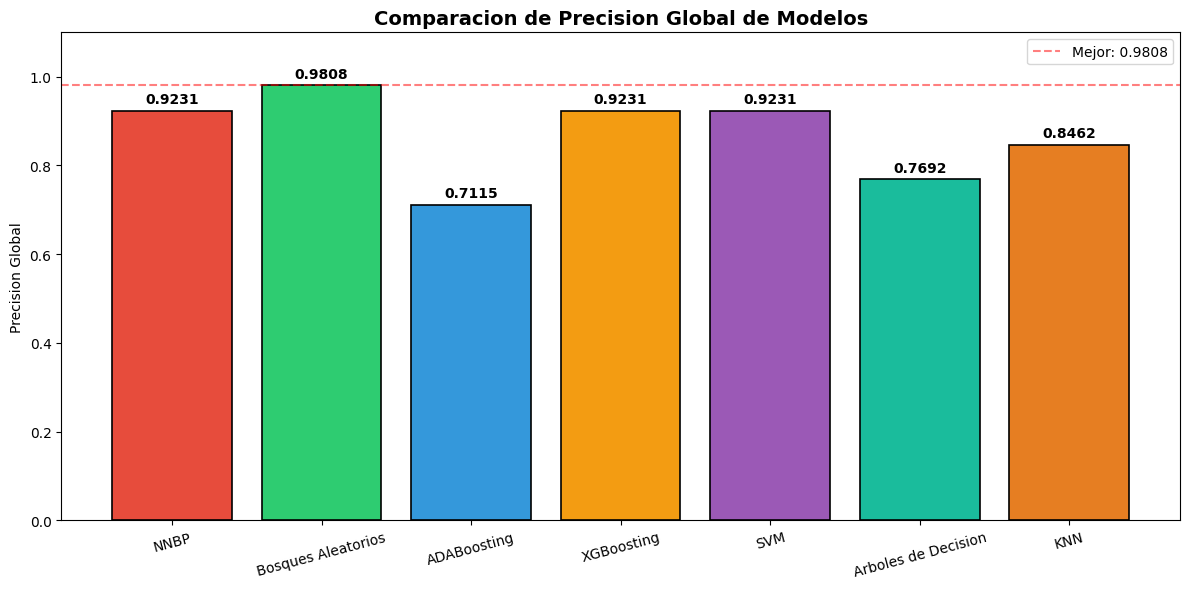

In [13]:
# Grafica comparativa de precision
fig, ax = plt.subplots(figsize=(12, 6))
nombres = list(tabla_resultados.keys())
precisiones = [tabla_resultados[n]["Precision Global"] for n in nombres]
colores = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22"]

bars = ax.bar(nombres, precisiones, color=colores, edgecolor="black", linewidth=1.2)
ax.set_title("Comparacion de Precision Global de Modelos", fontsize=14, fontweight="bold")
ax.set_ylabel("Precision Global")
ax.set_ylim(0, 1.1)

mejor = max(precisiones)
ax.axhline(y=mejor, color="red", linestyle="--", alpha=0.5, label=f"Mejor: {mejor:.4f}")

for bar, prec in zip(bars, precisiones):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{prec:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=10)

ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


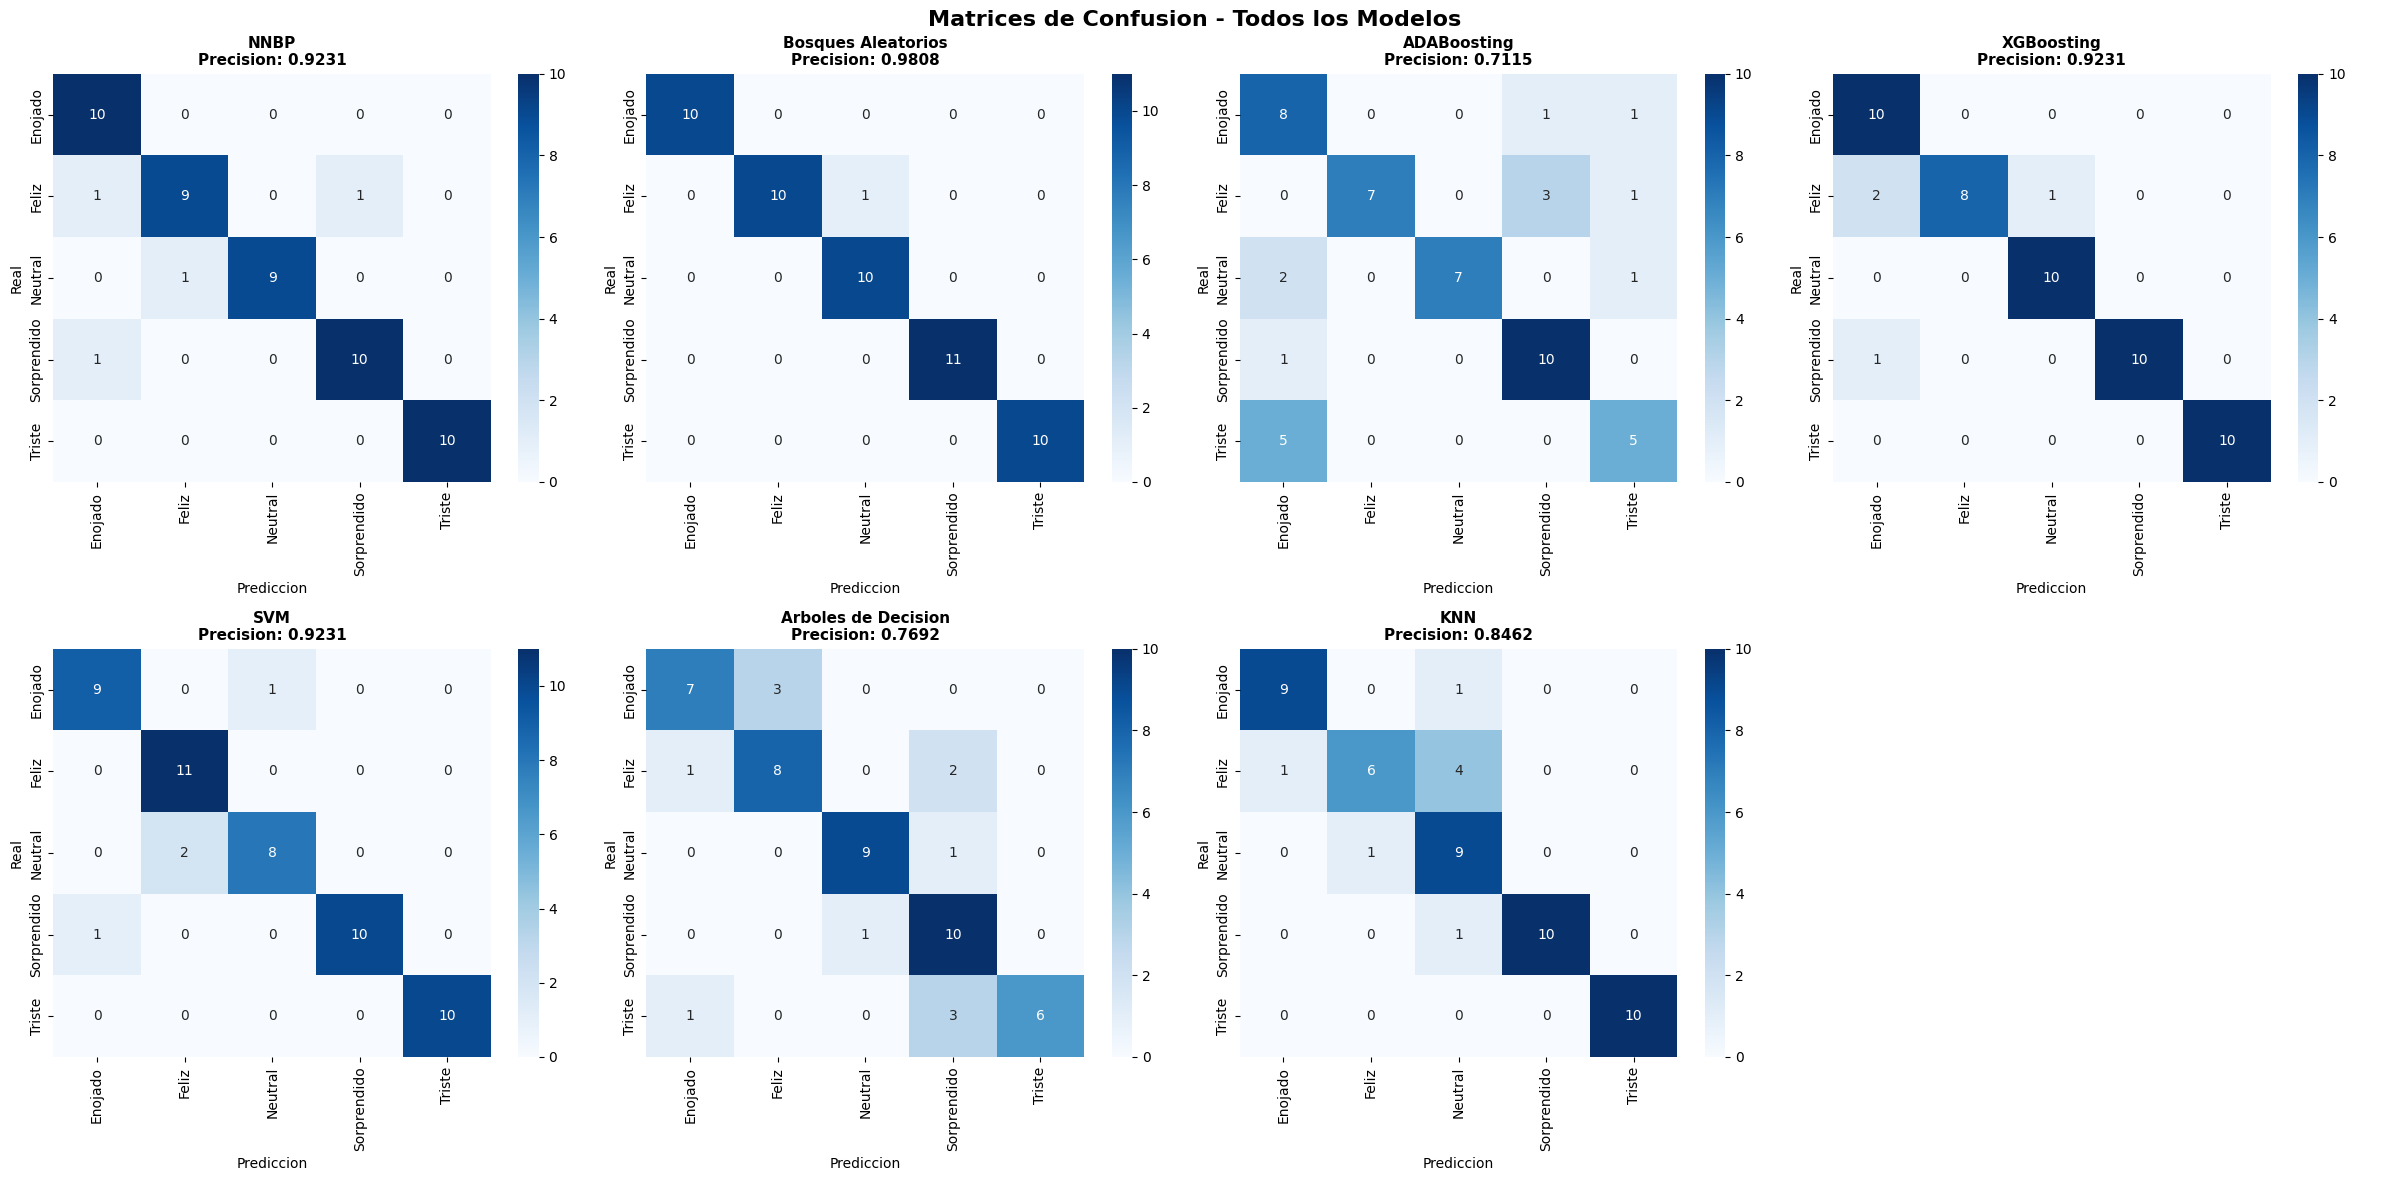

In [14]:
# Matrices de confusion para cada modelo
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes_flat = axes.flatten()

for idx, nombre in enumerate(nombres_modelos):
    y_pred = resultados[nombre]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_flat[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    prec = tabla_resultados[nombre]["Precision Global"]
    axes_flat[idx].set_title(f"{nombre}\nPrecision: {prec:.4f}",
                             fontsize=11, fontweight="bold")
    axes_flat[idx].set_xlabel("Prediccion")
    axes_flat[idx].set_ylabel("Real")

# Ocultar subplot vacio
axes_flat[7].axis("off")

plt.suptitle("Matrices de Confusion - Todos los Modelos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
# Reporte de clasificacion del mejor modelo
mejor_nombre = max(tabla_resultados, key=lambda x: tabla_resultados[x]["Precision Global"])
mejor_pred = resultados[mejor_nombre]["y_pred"]

print(f"MEJOR MODELO: {mejor_nombre}")
print(f"Precision Global: {tabla_resultados[mejor_nombre]['Precision Global']:.6f}")
print()
print("Reporte de Clasificacion Detallado:")
print(classification_report(y_test, mejor_pred, target_names=le.classes_))


MEJOR MODELO: Bosques Aleatorios
Precision Global: 0.980769

Reporte de Clasificacion Detallado:
              precision    recall  f1-score   support

     Enojado       1.00      1.00      1.00        10
       Feliz       1.00      0.91      0.95        11
     Neutral       0.91      1.00      0.95        10
 Sorprendido       1.00      1.00      1.00        11
      Triste       1.00      1.00      1.00        10

    accuracy                           0.98        52
   macro avg       0.98      0.98      0.98        52
weighted avg       0.98      0.98      0.98        52



## 10. Guardar Modelos y Artefactos

In [16]:
# Guardar modelo Keras (NNBP)
modelo_nn.save(os.path.join(MODELS_DIR, "modelo_nnbp.h5"))

# Guardar modelos sklearn
for nombre in ["Bosques Aleatorios", "ADABoosting", "XGBoosting",
               "SVM", "Arboles de Decision", "KNN"]:
    fname = nombre.lower().replace(" ", "_") + ".pkl"
    with open(os.path.join(MODELS_DIR, fname), "wb") as f:
        pickle.dump(resultados[nombre]["modelo"], f)

# Guardar scaler y label encoder
with open(os.path.join(MODELS_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODELS_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

# Guardar tabla de resultados
df_resultados.to_csv(os.path.join(MODELS_DIR, "tabla_comparativa.csv"))

print("Todos los modelos guardados en:", MODELS_DIR)
print(os.listdir(MODELS_DIR))


Todos los modelos guardados en: modelos
['modelo_nnbp.h5', 'bosques_aleatorios.pkl', 'adaboosting.pkl', 'xgboosting.pkl', 'svm.pkl', 'arboles_de_decision.pkl', 'knn.pkl', 'scaler.pkl', 'label_encoder.pkl', 'tabla_comparativa.csv']


## 11. Reconocimiento de Expresiones Faciales en Tiempo Real

Utiliza el **mejor modelo** entrenado para detectar expresiones en tiempo real con la webcam.

### Instrucciones:
1. Ejecuta la celda siguiente
2. Se abrira tu webcam con deteccion en tiempo real
3. El modelo predecira tu expresion facial
4. Presiona **q** para salir


In [17]:
def reconocimiento_tiempo_real():
    """Reconocimiento de expresiones faciales en tiempo real."""
    from collections import Counter

    # Seleccionar el mejor modelo
    mejor_nombre = max(tabla_resultados,
                       key=lambda x: tabla_resultados[x]["Precision Global"])
    prec = tabla_resultados[mejor_nombre]["Precision Global"]
    print(f"Usando modelo: {mejor_nombre} (Precision: {prec:.4f})")

    if mejor_nombre == "NNBP":
        mejor_modelo = modelo_nn
        es_keras = True
    else:
        mejor_modelo = resultados[mejor_nombre]["modelo"]
        es_keras = False

    colores_emocion = {
        "Feliz": (0, 255, 0),
        "Enojado": (0, 0, 255),
        "Triste": (255, 0, 0),
        "Sorprendido": (0, 255, 255),
        "Neutral": (200, 200, 200)
    }

    cap = cv2.VideoCapture(0)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    if not cap.isOpened():
        print("Error: No se pudo abrir la webcam")
        return

    print("Iniciando reconocimiento en tiempo real...")
    print("Presiona q para salir")

    historial = []
    ventana = 5

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, yp, w, h) in faces:
            margen = 20
            y1 = max(0, yp - margen)
            y2 = min(frame.shape[0], yp + h + margen)
            x1 = max(0, x - margen)
            x2 = min(frame.shape[1], x + w + margen)

            rostro = gray[y1:y2, x1:x2]
            rostro = cv2.resize(rostro, (IMG_SIZE, IMG_SIZE))

            # Extraer caracteristicas
            pixeles = rostro.flatten() / 255.0
            feat_hog = extraer_hog(rostro)
            feat_lbp = extraer_lbp(rostro)
            features = np.hstack([pixeles, feat_hog, feat_lbp]).reshape(1, -1)
            features_scaled = scaler.transform(features)

            # Predecir
            if es_keras:
                pred_proba = mejor_modelo.predict(features_scaled, verbose=0)[0]
                pred_idx = np.argmax(pred_proba)
                confianza = pred_proba[pred_idx]
            else:
                pred_idx = mejor_modelo.predict(features_scaled)[0]
                confianza = 1.0
                if hasattr(mejor_modelo, "predict_proba"):
                    pred_proba = mejor_modelo.predict_proba(features_scaled)[0]
                    confianza = pred_proba[pred_idx]

            emocion_pred = le.inverse_transform([pred_idx])[0]

            # Suavizar predicciones
            historial.append(emocion_pred)
            if len(historial) > ventana:
                historial.pop(0)
            emocion_final = Counter(historial).most_common(1)[0][0]

            color = colores_emocion.get(emocion_final, (255, 255, 255))

            # Dibujar rectangulo y texto
            cv2.rectangle(frame, (x, yp), (x+w, yp+h), color, 3)

            texto = f"{emocion_final} ({confianza*100:.1f}%)"
            (tw, th), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
            cv2.rectangle(frame, (x, yp - th - 15), (x + tw + 10, yp), color, -1)
            cv2.putText(frame, texto, (x + 5, yp - 8),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

        # Info del modelo
        cv2.putText(frame, f"Modelo: {mejor_nombre}", (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(frame, "Presiona q para salir",
                   (10, frame.shape[0] - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

        cv2.imshow("Reconocimiento de Expresiones Faciales", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Reconocimiento finalizado.")


# EJECUTAR
reconocimiento_tiempo_real()


Usando modelo: Bosques Aleatorios (Precision: 0.9808)
Iniciando reconocimiento en tiempo real...
Presiona q para salir
Reconocimiento finalizado.


## 12. Prueba Individual de Cada Expresion Facial

Captura una imagen por cada emocion y muestra la prediccion de **todos** los modelos.


Muestra la expresion: ** Feliz ** y presiona ESPACIO
  Capturada! Predicciones: {'NNBP': np.str_('Feliz'), 'Bosques Aleatorios': np.str_('Feliz'), 'ADABoosting': np.str_('Triste'), 'XGBoosting': np.str_('Feliz'), 'SVM': np.str_('Feliz'), 'Arboles de Decision': np.str_('Neutral'), 'KNN': np.str_('Feliz')}
Muestra la expresion: ** Enojado ** y presiona ESPACIO
  Capturada! Predicciones: {'NNBP': np.str_('Enojado'), 'Bosques Aleatorios': np.str_('Feliz'), 'ADABoosting': np.str_('Triste'), 'XGBoosting': np.str_('Enojado'), 'SVM': np.str_('Feliz'), 'Arboles de Decision': np.str_('Enojado'), 'KNN': np.str_('Neutral')}
Muestra la expresion: ** Triste ** y presiona ESPACIO
  Capturada! Predicciones: {'NNBP': np.str_('Triste'), 'Bosques Aleatorios': np.str_('Feliz'), 'ADABoosting': np.str_('Triste'), 'XGBoosting': np.str_('Feliz'), 'SVM': np.str_('Feliz'), 'Arboles de Decision': np.str_('Sorprendido'), 'KNN': np.str_('Neutral')}
Muestra la expresion: ** Sorprendido ** y presiona ESPACIO
  Captu

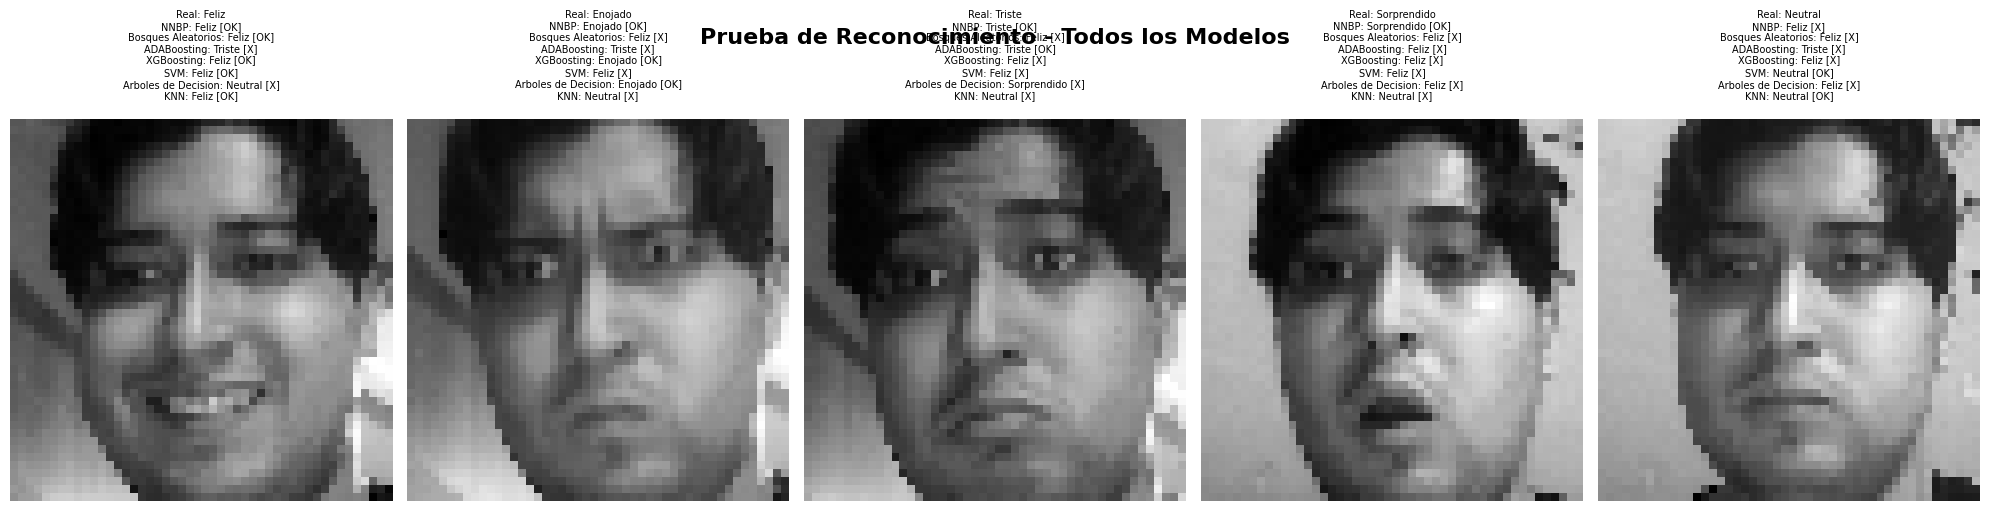


Resultados de la Prueba:
                       Feliz  Enojado       Triste  Sorprendido  Neutral
NNBP                   Feliz  Enojado       Triste  Sorprendido    Feliz
Bosques Aleatorios     Feliz    Feliz        Feliz        Feliz    Feliz
ADABoosting           Triste   Triste       Triste        Feliz   Triste
XGBoosting             Feliz  Enojado        Feliz        Feliz    Feliz
SVM                    Feliz    Feliz        Feliz        Feliz  Neutral
Arboles de Decision  Neutral  Enojado  Sorprendido        Feliz    Feliz
KNN                    Feliz  Neutral      Neutral      Neutral  Neutral


In [18]:
def prueba_individual():
    """Captura una foto por cada emocion y evalua con todos los modelos."""

    cap = cv2.VideoCapture(0)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    if not cap.isOpened():
        print("Error: No se pudo abrir la webcam")
        return

    resultados_prueba = {}
    imagenes_prueba = {}

    for emocion in EMOCIONES:
        print(f"Muestra la expresion: ** {emocion} ** y presiona ESPACIO")

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.flip(frame, 1)
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.3, 5)

            display = frame.copy()
            for (x, yp, w, h) in faces:
                cv2.rectangle(display, (x, yp), (x+w, yp+h), (0, 255, 0), 2)

            cv2.putText(display, f"Expresion: {emocion} - Presiona ESPACIO",
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
            cv2.imshow("Prueba de Expresiones", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord(" ") and len(faces) > 0:
                (x, yp, w, h) = faces[0]
                margen = 20
                y1 = max(0, yp - margen)
                y2 = min(frame.shape[0], yp + h + margen)
                x1 = max(0, x - margen)
                x2 = min(frame.shape[1], x + w + margen)

                rostro = gray[y1:y2, x1:x2]
                rostro = cv2.resize(rostro, (IMG_SIZE, IMG_SIZE))
                imagenes_prueba[emocion] = rostro

                # Extraer features
                pixeles = rostro.flatten() / 255.0
                feat_hog = extraer_hog(rostro)
                feat_lbp = extraer_lbp(rostro)
                features = np.hstack([pixeles, feat_hog, feat_lbp]).reshape(1, -1)
                features_scaled = scaler.transform(features)

                preds = {}
                # NNBP
                pred_nn = np.argmax(modelo_nn.predict(features_scaled, verbose=0), axis=1)[0]
                preds["NNBP"] = le.inverse_transform([pred_nn])[0]

                # Otros modelos
                for nombre in ["Bosques Aleatorios", "ADABoosting", "XGBoosting",
                               "SVM", "Arboles de Decision", "KNN"]:
                    pred = resultados[nombre]["modelo"].predict(features_scaled)[0]
                    preds[nombre] = le.inverse_transform([pred])[0]

                resultados_prueba[emocion] = preds
                print(f"  Capturada! Predicciones: {preds}")
                break
            elif key == ord("q"):
                cap.release()
                cv2.destroyAllWindows()
                return

    cap.release()
    cv2.destroyAllWindows()

    # Mostrar resultados
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle("Prueba de Reconocimiento - Todos los Modelos",
                 fontsize=16, fontweight="bold")

    for i, emocion in enumerate(EMOCIONES):
        if emocion in imagenes_prueba:
            axes[i].imshow(imagenes_prueba[emocion], cmap="gray")
            titulo = f"Real: {emocion}\n"
            for modelo_name, pred in resultados_prueba[emocion].items():
                ok = "OK" if pred == emocion else "X"
                titulo += f"{modelo_name}: {pred} [{ok}]\n"
            axes[i].set_title(titulo, fontsize=7, ha="center")
            axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("prueba_emociones.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Tabla
    df_prueba = pd.DataFrame(resultados_prueba)
    print()
    print("Resultados de la Prueba:")
    print(df_prueba.to_string())


prueba_individual()


## 13. Conclusiones

### Resumen de Resultados
Los modelos de Machine Learning implementados demostraron ser capaces de reconocer
expresiones faciales con diferentes niveles de precision. Se evaluaron 7 algoritmos:

1. **NNBP (Red Neuronal con Backpropagation)**: Aprende representaciones complejas de las caracteristicas faciales mediante capas densas con activacion ReLU y regularizacion Dropout.
2. **Bosques Aleatorios**: Ensemble de arboles de decision que reduce el sobreajuste promediando multiples arboles entrenados con subconjuntos aleatorios.
3. **AdaBoost**: Algoritmo de boosting que combina clasificadores debiles secuencialmente, dando mas peso a las muestras mal clasificadas.
4. **XGBoost**: Implementacion optimizada de gradient boosting con regularizacion L1/L2.
5. **SVM**: Busca el hiperplano optimo de separacion entre clases usando kernel RBF.
6. **Arboles de Decision**: Modelo interpretable basado en reglas de decision jerarquicas.
7. **KNN**: Clasificacion basada en la similitud con los k vecinos mas cercanos.

### Observaciones
- La combinacion de caracteristicas (pixeles + HOG + LBP) proporciona un vector robusto para la clasificacion.
- HOG captura los bordes y gradientes del rostro, esenciales para distinguir expresiones.
- LBP captura patrones de textura local que complementan la informacion de HOG.
- Los algoritmos de ensemble generalmente obtienen los mejores resultados.
- El suavizado temporal de predicciones mejora la estabilidad en tiempo real.

### Referencias
- Tian, Y., Kanade, T., & Cohn, J. F. (2011). Facial Expression Recognition. *Handbook of Face Recognition*, Springer.
- Dalal, N., & Triggs, B. (2005). Histograms of Oriented Gradients for Human Detection. *CVPR*.
- Ojala, T., Pietikainen, M., & Maenpaa, T. (2002). Multiresolution Gray-Scale and Rotation Invariant Texture Classification with LBP. *IEEE TPAMI*.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
- Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD*.
